# Stats

In [79]:
import pandas as pd
import nibabel as nib
from glob import glob
import numpy as np
import statsmodels.api as sp
#imported the full paths since it wasn't working otherwise - not sure why 
from statsmodels.stats.weightstats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.regression.linear_model import OLS

In [80]:
df_tabular = pd.read_csv('../resources/merged_tabular_withconn_flipped.tsv',sep='\t')

## T-Test

### RSFC

In [8]:
# Split the dataset into two groups: 'LOBE' and 'HCP'
group_lobe = df_tabular[df_tabular['dataset'] == 'LOBE']
group_hcp = df_tabular[df_tabular['dataset'] == 'HCP']

# Identify columns that start with 'R_'
r_columns = [col for col in df_tabular.columns if col.startswith('RSFC_')]

# Lists to store t-test results
tstats_list, pvals_list, dfs_list = [], [], []

# Run t-test for each 'R_' column
for col in r_columns:
    x1 = group_lobe[col]
    x2 = group_hcp[col]
    
    # Perform the t-test
    tstat, pval, df = ttest_ind(x1, x2, alternative='two-sided', usevar='pooled')
    
    # Store results
    tstats_list.append(tstat)
    pvals_list.append(pval)
    dfs_list.append(df)

# Apply FDR correction
rejected, corr_pvals = fdrcorrection(pvals_list, alpha=0.05, method='indep', is_sorted=False)

# Store results in a DataFrame
results_df = pd.DataFrame({
    'R_column': r_columns,
    't-statistic': tstats_list,
    'raw p-value': pvals_list,
    'corrected p-value': corr_pvals,
    'rejected (FDR significant)': rejected,
    'degrees_of_freedom': dfs_list
})

# Display the results
print(results_df)

# Save the DataFrame as a TSV file
results_df.to_csv('../results/stats_Mar25/ttest_rsfc_fdr_results.tsv', sep='\t', index=False)

# Filter the DataFrame to only include significant results (rejected == True)
significant_results_df = results_df[results_df['rejected (FDR significant)']]

# Save the filtered results as a TSV file
significant_results_df.to_csv('../results/stats_Mar25/ttest_rsfc_fdr_significant_results.tsv', sep='\t', index=False)


                       R_column  t-statistic  raw p-value  corrected p-value  \
0            RSFC_ipsi_A8m_Cont     0.228125     0.819680           0.906745   
1          RSFC_contra_A8m_Cont    -0.995968     0.319942           0.600808   
2        RSFC_ipsi_A8dl_Default     1.008954     0.313682           0.595017   
3      RSFC_contra_A8dl_Default     1.614973     0.107202           0.393609   
4         RSFC_ipsi_A9l_Default    -0.054760     0.956360           0.972168   
..                          ...          ...          ...                ...   
241    RSFC_contra_Otha_Subcort    -2.688653     0.007511           0.093665   
242     RSFC_ipsi_cTtha_Subcort    -1.373878     0.170344           0.450587   
243   RSFC_contra_cTtha_Subcort    -1.320842     0.187403           0.461010   
244    RSFC_ipsi_lPFtha_Subcort    -1.199019     0.231318           0.496778   
245  RSFC_contra_lPFtha_Subcort     0.520067     0.603340           0.811048   

     rejected (FDR significant)  degree

### RSC

In [9]:
# Split the dataset into two groups: 'LOBE' and 'HCP'
group_lobe = df_tabular[df_tabular['dataset'] == 'LOBE']
group_hcp = df_tabular[df_tabular['dataset'] == 'HCP']

# Identify columns that start with 'R_'
r_columns = [col for col in df_tabular.columns if col.startswith('RSC_')]

# Lists to store t-test results
tstats_list, pvals_list, dfs_list = [], [], []

# Run t-test for each 'R_' column
for col in r_columns:
    x1 = group_lobe[col]
    x2 = group_hcp[col]
    
    # Perform the t-test
    tstat, pval, df = ttest_ind(x1, x2, alternative='two-sided', usevar='pooled')
    
    # Store results
    tstats_list.append(tstat)
    pvals_list.append(pval)
    dfs_list.append(df)

# Apply FDR correction
rejected, corr_pvals = fdrcorrection(pvals_list, alpha=0.05, method='indep', is_sorted=False)

# Store results in a DataFrame
results_df = pd.DataFrame({
    'R_column': r_columns,
    't-statistic': tstats_list,
    'raw p-value': pvals_list,
    'corrected p-value': corr_pvals,
    'rejected (FDR significant)': rejected,
    'degrees_of_freedom': dfs_list
})

# Display the results
print(results_df)

# Save the DataFrame as a TSV file
results_df.to_csv('../results/stats_Mar25/ttest_rsc_fdr_results.tsv', sep='\t', index=False)

# Filter the DataFrame to only include significant results (rejected == True)
significant_results_df = results_df[results_df['rejected (FDR significant)']]

# Save the filtered results as a TSV file
significant_results_df.to_csv('../results/stats_Mar25/ttest_rsc_fdr_significant_results.tsv', sep='\t', index=False)


                      R_column  t-statistic  raw p-value  corrected p-value  \
0            RSC_ipsi_A8m_Cont     0.744137     0.457284           0.685386   
1          RSC_contra_A8m_Cont    -1.053540     0.292808           0.587853   
2        RSC_ipsi_A8dl_Default    -0.553790     0.580070           0.758961   
3      RSC_contra_A8dl_Default    -0.005592     0.995541           0.999094   
4         RSC_ipsi_A9l_Default     0.309150     0.757388           0.839268   
..                         ...          ...          ...                ...   
241    RSC_contra_Otha_Subcort     3.483973     0.000556           0.019527   
242     RSC_ipsi_cTtha_Subcort     0.849279     0.396297           0.642602   
243   RSC_contra_cTtha_Subcort     2.008417     0.045354           0.196698   
244    RSC_ipsi_lPFtha_Subcort    -1.015718     0.310453           0.596566   
245  RSC_contra_lPFtha_Subcort    -2.371790     0.018233           0.119552   

     rejected (FDR significant)  degrees_of_freedom

### FC

In [10]:
# Split the dataset into two groups: 'LOBE' and 'HCP'
group_lobe = df_tabular[df_tabular['dataset'] == 'LOBE']
group_hcp = df_tabular[df_tabular['dataset'] == 'HCP']

# Identify columns that start with 'R_'
r_columns = [col for col in df_tabular.columns if col.startswith('RFC_')]

# Lists to store t-test results
tstats_list, pvals_list, dfs_list = [], [], []

# Run t-test for each 'R_' column
for col in r_columns:
    x1 = group_lobe[col]
    x2 = group_hcp[col]
    
    # Perform the t-test
    tstat, pval, df = ttest_ind(x1, x2, alternative='two-sided', usevar='pooled')
    
    # Store results
    tstats_list.append(tstat)
    pvals_list.append(pval)
    dfs_list.append(df)

# Apply FDR correction
rejected, corr_pvals = fdrcorrection(pvals_list, alpha=0.05, method='indep', is_sorted=False)

# Store results in a DataFrame
results_df = pd.DataFrame({
    'R_column': r_columns,
    't-statistic': tstats_list,
    'raw p-value': pvals_list,
    'corrected p-value': corr_pvals,
    'rejected (FDR significant)': rejected,
    'degrees_of_freedom': dfs_list
})

# Display the results
print(results_df)

# Save the DataFrame as a TSV file
results_df.to_csv('../results/stats_Mar25/ttest_rfc_fdr_results.tsv', sep='\t', index=False)

# Filter the DataFrame to only include significant results (rejected == True)
significant_results_df = results_df[results_df['rejected (FDR significant)']]

# Save the filtered results as a TSV file
significant_results_df.to_csv('../results/stats_Mar25/ttest_rfc_fdr_significant_results.tsv', sep='\t', index=False)


                      R_column  t-statistic  raw p-value  corrected p-value  \
0            RFC_ipsi_A8m_Cont     1.976463     0.048874           0.370518   
1          RFC_contra_A8m_Cont     0.641176     0.521821           0.711074   
2        RFC_ipsi_A8dl_Default     2.390008     0.017367           0.370518   
3      RFC_contra_A8dl_Default     1.058325     0.290625           0.551550   
4         RFC_ipsi_A9l_Default     2.460720     0.014340           0.370518   
..                         ...          ...          ...                ...   
241    RFC_contra_Otha_Subcort    -0.045136     0.964025           0.987376   
242     RFC_ipsi_cTtha_Subcort     0.235638     0.813849           0.914186   
243   RFC_contra_cTtha_Subcort     0.032113     0.974400           0.989669   
244    RFC_ipsi_lPFtha_Subcort    -0.432045     0.665970           0.804365   
245  RFC_contra_lPFtha_Subcort    -0.839529     0.401736           0.650716   

     rejected (FDR significant)  degrees_of_freedom

## Linear Model

In [42]:
# update file being read in 

In [81]:
df_tabular = pd.read_csv('../resources/merged_tabular_withconn_flipped.tsv',sep='\t')

# Convert 'sex' to numeric if it's categorical (assuming 'male' and 'female')
df_tabular['sex'] = df_tabular['sex'].map({'M': 1, 'F': 0})

# Convert 'dataset' to numeric (LOBE = 0, HCP = 1)
df_tabular['dataset'] = df_tabular['dataset'].map({'LOBE': 1, 'HCP': 0})


# Identify columns that start with 'R_'
r_columns = [col for col in df_tabular.columns if col.startswith('RSFC_')]

# Lists to store results
model_params, pvals_list = [], []

# Loop over each R_ column to fit the OLS model
for col in r_columns:
    # Define the independent variables (covariates + dataset)
    X = df_tabular[['age', 'sex', 'dataset']]
    
    # Add a constant term (intercept) to the model
    X = sp.add_constant(X)
    
    # Define the dependent variable (R_ column)
    y = df_tabular[col]
    
    # Fit the OLS model
    model = sp.OLS(y, X).fit()
    
    # Get the p-value and coefficient for the 'dataset' variable (testing for difference between LOBE and HCP)
    model_params.append(model.params['dataset'])
    pvals_list.append(model.pvalues['dataset'])

# Store the results in a DataFrame
results_df = pd.DataFrame({
    'RSFC_column': r_columns,
    'dataset_coefficient': model_params,
    'p-value': pvals_list
})

# Apply FDR correction for multiple comparisons
rejected, corr_pvals = fdrcorrection(pvals_list, alpha=0.05)

# Add FDR-corrected p-values and rejected boolean to the results
results_df['corrected p-value'] = corr_pvals
results_df['rejected (FDR significant)'] = rejected

# Save the results to a TSV file
results_df.to_csv('../results/stats_Mar25/ols_rsfc_results_with_covariates.tsv', sep='\t', index=False)

# Filter the DataFrame to only include significant results (rejected == True)
significant_results_df = results_df[results_df['rejected (FDR significant)']]

# Save the filtered results as a TSV file
significant_results_df.to_csv('../results/stats_Mar25/ols_rsfc_fdr_significant_results.tsv', sep='\t', index=False)

In [82]:
    X = df_tabular[['age', 'sex', 'dataset']]
    
    # Add a constant term (intercept) to the model
    X = sp.add_constant(X)
    
    # Define the dependent variable (R_ column)
    y = df_tabular['RSFC_ipsi_A10l_Default']
    
    # Fit the OLS model
    model = sp.OLS(y, X).fit()
    
    # Get the p-value and coefficient for the 'dataset' variable (testing for difference between LOBE and HCP)
    model_params.append(model.params['dataset'])
    pvals_list.append(model.pvalues['dataset'])

In [83]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     RSFC_ipsi_A10l_Default   R-squared:                       0.039
Model:                                OLS   Adj. R-squared:                  0.031
Method:                     Least Squares   F-statistic:                     4.859
Date:                    Wed, 02 Apr 2025   Prob (F-statistic):            0.00251
Time:                            00:04:25   Log-Likelihood:                 319.92
No. Observations:                     362   AIC:                            -631.8
Df Residuals:                         358   BIC:                            -616.3
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1960      0.025      7.842      0.000       0.147       0.245
age           -0.0008      0.002     -0.454      0.650      -0.004       0.003
sex            0.0177      0.011      1.673      0.095      -0.003       0.039
dataset       -0.0788      0.023     -3.472      0.001      -0.123      -0.034
==============================================================================
Omnibus:                       17.823   Durbin-Watson:                   2.052
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.446
Skew:                          -0.504   Prob(JB):                     5.99e-05
Kurtosis:                       3.523   Cond. No.                         65.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### FC

In [84]:
df_tabular = pd.read_csv('../resources/merged_tabular_withconn_flipped.tsv',sep='\t')

# Convert 'sex' to numeric if it's categorical (assuming 'male' and 'female')
df_tabular['sex'] = df_tabular['sex'].map({'M': 1, 'F': 0})

# Convert 'dataset' to numeric (LOBE = 0, HCP = 1)
df_tabular['dataset'] = df_tabular['dataset'].map({'LOBE': 1, 'HCP': 0})


# Identify columns that start with 'R_'
r_columns = [col for col in df_tabular.columns if col.startswith('RFC_')]

# Lists to store results
model_params, pvals_list = [], []

# Loop over each R_ column to fit the OLS model
for col in r_columns:
    # Define the independent variables (covariates + dataset)
    X = df_tabular[['age', 'sex', 'dataset']]
    
    # Add a constant term (intercept) to the model
    X = sp.add_constant(X)
    
    # Define the dependent variable (R_ column)
    y = df_tabular[col]
    
    # Fit the OLS model
    model = sp.OLS(y, X).fit()
    
    # Get the p-value and coefficient for the 'dataset' variable (testing for difference between LOBE and HCP)
    model_params.append(model.params['dataset'])
    pvals_list.append(model.pvalues['dataset'])

# Store the results in a DataFrame
results_df = pd.DataFrame({
    'RFC_column': r_columns,
    'dataset_coefficient': model_params,
    'p-value': pvals_list
})

# Apply FDR correction for multiple comparisons
rejected, corr_pvals = fdrcorrection(pvals_list, alpha=0.05)

# Add FDR-corrected p-values and rejected boolean to the results
results_df['corrected p-value'] = corr_pvals
results_df['rejected (FDR significant)'] = rejected

# Save the results to a TSV file
results_df.to_csv('../results/stats_Mar25/ols_rfc_results_with_covariates.tsv', sep='\t', index=False)

# Filter the DataFrame to only include significant results (rejected == True)
significant_results_df = results_df[results_df['rejected (FDR significant)']]

# Save the filtered results as a TSV file
significant_results_df.to_csv('../results/stats_Mar25/ols_rfc_fdr_significant_results.tsv', sep='\t', index=False)

### SC

In [85]:
df_tabular = pd.read_csv('../resources/merged_tabular_withconn_flipped.tsv',sep='\t')

# Convert 'sex' to numeric if it's categorical (assuming 'male' and 'female')
df_tabular['sex'] = df_tabular['sex'].map({'M': 1, 'F': 0})

# Convert 'dataset' to numeric (LOBE = 0, HCP = 1)
df_tabular['dataset'] = df_tabular['dataset'].map({'LOBE': 1, 'HCP': 0})


# Identify columns that start with 'R_'
r_columns = [col for col in df_tabular.columns if col.startswith('RSC_')]

# Lists to store results
model_params, pvals_list = [], []

# Loop over each R_ column to fit the OLS model
for col in r_columns:
    # Define the independent variables (covariates + dataset)
    X = df_tabular[['age', 'sex', 'dataset']]
    
    # Add a constant term (intercept) to the model
    X = sp.add_constant(X)
    
    # Define the dependent variable (R_ column)
    y = df_tabular[col]
    
    # Fit the OLS model
    model = sp.OLS(y, X).fit()
    
    # Get the p-value and coefficient for the 'dataset' variable (testing for difference between LOBE and HCP)
    model_params.append(model.params['dataset'])
    pvals_list.append(model.pvalues['dataset'])

# Store the results in a DataFrame
results_df = pd.DataFrame({
    'RSC_column': r_columns,
    'dataset_coefficient': model_params,
    'p-value': pvals_list
})

# Apply FDR correction for multiple comparisons
rejected, corr_pvals = fdrcorrection(pvals_list, alpha=0.05)

# Add FDR-corrected p-values and rejected boolean to the results
results_df['corrected p-value'] = corr_pvals
results_df['rejected (FDR significant)'] = rejected

# Save the results to a TSV file
results_df.to_csv('../results/stats_Mar25/ols_rsc_results_with_covariates.tsv', sep='\t', index=False)

# Filter the DataFrame to only include significant results (rejected == True)
significant_results_df = results_df[results_df['rejected (FDR significant)']]

# Save the filtered results as a TSV file
significant_results_df.to_csv('../results/stats_Mar25/ols_rsc_fdr_significant_results.tsv', sep='\t', index=False)

# ANOVA

## Check normality

In [47]:
right_sided_subs_lobe = ['006','010','014','017','020','025','028','029','035', '038', '041']  # Example list of subject IDs to rearrange


In [48]:
left_sided_subs_lobe = ['007','009','012','013','015','019','022','026','027', '031']

In [50]:
from scipy import stats
df_tabular = pd.read_csv('../resources/merged_tabular_withconn_flipped.bkup.tsv',sep='\t')

In [58]:
# Define functions to classify participants into groups
def classify_group(row):
    if row['dataset'] == 'HCP':
        return 'HCP'
    elif row['dataset'] == 'LOBE':
        sub_id = row['participant_id'].split('-')[-1]
        if sub_id in right_sided_subs_lobe:
            return 'Right_Lobe'
        elif sub_id in left_sided_subs_lobe:
            return 'Left_Lobe'
    return None  # For rows that don't match any condition

# Add a new column 'group' to classify participants
df_tabular['group'] = df_tabular.apply(classify_group, axis=1)

# Filter out rows where 'group' is None (non-matching rows)
df_tabular = df_tabular[df_tabular['group'].notna()]

# Identify columns that you want to perform ANOVA on (for example, columns starting with 'R_')
anova_columns = [col for col in df_tabular.columns if col.startswith('RSFC_')]

# Run ANOVA for each 'R_' column
anova_results = {}
for col in anova_columns:
    # Separate data by groups
    group1 = df_tabular[df_tabular['group'] == 'HCP'][col]
    group2 = df_tabular[df_tabular['group'] == 'Right_Lobe'][col]
    group3 = df_tabular[df_tabular['group'] == 'Left_Lobe'][col]
    
    # Perform one-way ANOVA
    f_stat, p_val = stats.f_oneway(group1, group2, group3)
    
    # Store results
    anova_results[col] = {'F-statistic': f_stat, 'p-value': p_val}

# Apply FDR correction to the p-values
rejected, corrected_pvals = fdrcorrection(pvals_list, alpha=0.05, method='indep')

# Add the corrected p-values and significance status to the results
for i, col in enumerate(anova_columns):
    anova_results[col]['corrected p-value'] = corrected_pvals[i]
    anova_results[col]['rejected (FDR significant)'] = rejected[i]

# Convert results into a DataFrame for easier visualization
anova_df = pd.DataFrame.from_dict(anova_results, orient='index')

# Save the DataFrame as a TSV file
anova_df.to_csv('../results/stats_Mar25/anova_rsfc_fdr_results.tsv', sep='\t', index=False)

# Filter to only include rows where 'rejected (FDR significant)' is True
significant_anova_df = anova_df[anova_df['rejected (FDR significant)'] == True]

# Save the filtered DataFrame as a TSV file
significant_anova_df.to_csv('../results/stats_Mar25/anova__rsfc_fdr_significant_results.tsv', sep='\t', index=True)


# Display the results
print(significant_anova_df)

                             F-statistic       p-value  corrected p-value  \
RSFC_contra_A6dl_DorsAttn       3.463406  3.238531e-02           0.040761   
RSFC_ipsi_A10l_Default          2.353415  9.652535e-02           0.014260   
RSFC_ipsi_A38m_Limbic           3.137627  4.459125e-02           0.014260   
RSFC_contra_A38m_Limbic        22.673094  5.409990e-10           0.000108   
RSFC_ipsi_A20iv_Limbic          4.259256  1.486187e-02           0.028212   
RSFC_contra_A37elv_DorsAttn     8.748679  1.955082e-04           0.011031   
RSFC_contra_A20r_Limbic         9.847112  6.884392e-05           0.014260   
RSFC_contra_A37vl_DorsAttn      8.923928  1.654492e-04           0.011031   
RSFC_contra_A20cl_Cont         11.070831  2.167615e-05           0.005985   
RSFC_contra_A20rv_Limbic        5.701929  3.652800e-03           0.011031   
RSFC_contra_A35-36r_Limbic      7.914203  4.338364e-04           0.021421   
RSFC_ipsi_TL_Vis                5.079107  6.685623e-03           0.025554   

In [57]:
from scipy.stats import shapiro

from scipy.stats import kstest

# Kolmogorov-Smirnov Test for normality - The Kolmogorov-Smirnov test also tests for normality. It compares your data against a normal distribution. If the p-value is greater than 0.05, the data is likely normally distributed.
stat1, p1 = kstest(group1, 'norm')
stat2, p2 = kstest(group2, 'norm')
stat3, p3 = kstest(group3, 'norm')

print(f"HCP group: Statistics={stat1}, p-value={p1}")
print(f"Right_Lobe group: Statistics={stat2}, p-value={p2}")
print(f"Left_Lobe group: Statistics={stat3}, p-value={p3}")


HCP group: Statistics=0.4430710547001625, p-value=1.6460404090399443e-61
Right_Lobe group: Statistics=0.4933957666898952, p-value=0.015164228863663975
Left_Lobe group: Statistics=0.47155935408622457, p-value=0.03742585445988922


In [61]:
from scipy.stats import bartlett

# Perform Bartlett's test - Null hypothesis: The variances are equal. Alternative hypothesis: The variances are not equal.

stat, p_value = bartlett(group1, group2, group3)

print(f"Bartlett's Test: Statistics={stat}, p-value={p_value}")

if p_value > 0.05:
    print("Variances are equal (homogeneity of variances).")
else:
    print("Variances are NOT equal (violates homogeneity of variances assumption).")


Bartlett's Test: Statistics=0.5588826259088748, p-value=0.7562061060151414
Variances are equal (homogeneity of variances).


In [70]:
import pandas as pd

# Step 1: Load the TSV file with significant ANOVA results
significant_anova_df = pd.read_csv('../results/stats_Mar25/anova__rsfc_fdr_significant_results.tsv', sep='\t')

# Step 2: Extract the significant columns
# Assuming the column 'rejected (FDR significant)' indicates whether the column is significant
# You may need to adjust the column name based on your actual TSV structure
significant_columns = significant_anova_df[significant_anova_df['rejected (FDR significant)'] == True]['column_name'].tolist()

print("List of significant columns:", significant_columns)

# Step 3: Now you can use the significant_columns list to run Tukey's HSD test for each one
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


tukey_results = []

for col in significant_columns:
    #print(f"\nRunning Tukey HSD for {col}...\n")
    
    # Run Tukey HSD for each significant column
    tukey = pairwise_tukeyhsd(endog=df_tabular[col],  # dependent variable (column you're testing)
                              groups=df_tabular['group'],  # categorical group column (e.g., HCP, LOBE)
                              alpha=0.05)  # significance level
    # Convert Tukey results to DataFrame for saving
    tukey_df = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
    tukey_df['column_name'] = col  # Add column name for identification

    # Calculate the mean for each group (group1 and group2)
    for i, row in tukey_df.iterrows():
        group1 = row['group1']
        group2 = row['group2']
        
        # Calculate means for group1 and group2
        group1_mean = df_tabular[df_tabular['group'] == group1][col].mean()
        group2_mean = df_tabular[df_tabular['group'] == group2][col].mean()
        
        # Add means to the DataFrame
        tukey_df.loc[i, 'group1_mean'] = group1_mean
        tukey_df.loc[i, 'group2_mean'] = group2_mean
    
    # Append the DataFrame to the list
    tukey_results.append(tukey_df)
    
# Combine all Tukey results into one DataFrame
tukey_all_results = pd.concat(tukey_results)

# Save the combined results to a TSV file
tukey_all_results.to_csv('../results/stats_Mar25/rsfc_tukey_hsd_results.tsv', sep='\t', index=False)

# Filter only rows where 'reject' is True
tukey_significant_results = tukey_all_results[tukey_all_results['reject'] == True]

# Save the filtered results to a TSV file
tukey_significant_results.to_csv('../results/stats_Mar25/rsfc_tukey_hsd_significant_results.tsv', sep='\t', index=False)

print(tukey_results)

List of significant columns: ['RSFC_contra_A6dl_DorsAttn', 'RSFC_ipsi_A10l_Default', 'RSFC_ipsi_A38m_Limbic', 'RSFC_contra_A38m_Limbic', 'RSFC_ipsi_A20iv_Limbic', 'RSFC_contra_A37elv_DorsAttn', 'RSFC_contra_A20r_Limbic', 'RSFC_contra_A37vl_DorsAttn', 'RSFC_contra_A20cl_Cont', 'RSFC_contra_A20rv_Limbic', 'RSFC_contra_A35-36r_Limbic', 'RSFC_ipsi_TL_Vis', 'RSFC_ipsi_A40rv_SalVentAttn', 'RSFC_contra_lsOccG_Vis', 'RSFC_contra_mAmyg_Subcort', 'RSFC_contra_cHipp_Subcort']
[      group1      group2  meandiff   p-adj   lower   upper  reject  \
0        HCP   Left_Lobe    0.0884  0.0290  0.0072  0.1695    True   
1        HCP  Right_Lobe    0.0215  0.7865 -0.0551  0.0981   False   
2  Left_Lobe  Right_Lobe   -0.0669  0.3278 -0.1771  0.0434   False   

                 column_name  group1_mean  group2_mean  
0  RSFC_contra_A6dl_DorsAttn     0.234503     0.322875  
1  RSFC_contra_A6dl_DorsAttn     0.234503     0.256006  
2  RSFC_contra_A6dl_DorsAttn     0.322875     0.256006  ,       group1      g

# Left vs Right Sided Patients 

In [5]:
right_sided_subs_lobe = ['006','010','014','017','020','025','028','029','035', '038', '041']  # Example list of subject IDs to rearrange


In [6]:
left_sided_subs_lobe = ['007','009','012','013','015','019','022','026','027', '031']

In [9]:
import pandas as pd
from scipy.stats import ttest_rel

# Load the dataset
file_path = "../resources/merged_tabular_withconn_flipped.tsv"
df = pd.read_csv(file_path, sep='\t')

# Filter for LOBE participants
df_lobe = df[df['participant_id'].isin(left_sided_subs_lobe + right_sided_subs_lobe)]

# Extract the two columns for comparison
contra_values = df_lobe['RSFC_contra_A38m_Limbic']
ipsi_values = df_lobe['RSFC_ipsi_A38m_Limbic']

# Perform a paired t-test
t_stat, p_value = ttest_rel(contra_values, ipsi_values, nan_policy='omit')

# Print results
print(f"T-statistic: {t_stat}, P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Significant difference between contra and ipsi RSFC.")
else:
    print("No significant difference found.")


T-statistic: -0.9333413775258588, P-value: 0.36177580671730725
No significant difference found.


# Laterality Index

In [ ]:
# rename R and L in dataframe as 

In [68]:
import pandas as pd

# Load the dataset
file_path = "../resources/merged_tabular_withconn.tsv"
df = pd.read_csv(file_path, sep='\t')

# Identify ipsi and contra columns
left_cols = [col for col in df.columns if col.startswith('RSFC_L')]
right_cols = [col.replace('RSFC_L', 'RSFC_R') for col in left_cols]

# Ensure corresponding contra columns exist
valid_pairs = [(left,right) for left, right in zip(left_cols, right_cols) if right in df.columns]

# Create a new DataFrame to store laterality indices
laterality_df = df[['participant_id', 'age', 'sex', 'dataset']].copy()

# Compute laterality index for each pair
for left_col, right_col in valid_pairs:
    new_col_name = left_col.replace('RSFC_L', 'RSFC_LI')  # Preserve full name structure
    laterality_df[new_col_name] = (df[left_col] - df[right_col])

# Save the new DataFrame
output_path = "../resources/laterality_index.tsv"
laterality_df.to_csv(output_path, sep='\t', index=False)

print(f"Laterality index DataFrame saved to {output_path}")


Laterality index DataFrame saved to ../resources/laterality_index.tsv


/tmp/ipykernel_6718/831519833.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  laterality_df[new_col_name] = (df[left_col] - df[right_col])
/tmp/ipykernel_6718/831519833.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  laterality_df[new_col_name] = (df[left_col] - df[right_col])
/tmp/ipykernel_6718/831519833.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) i

In [20]:
# Plot one region

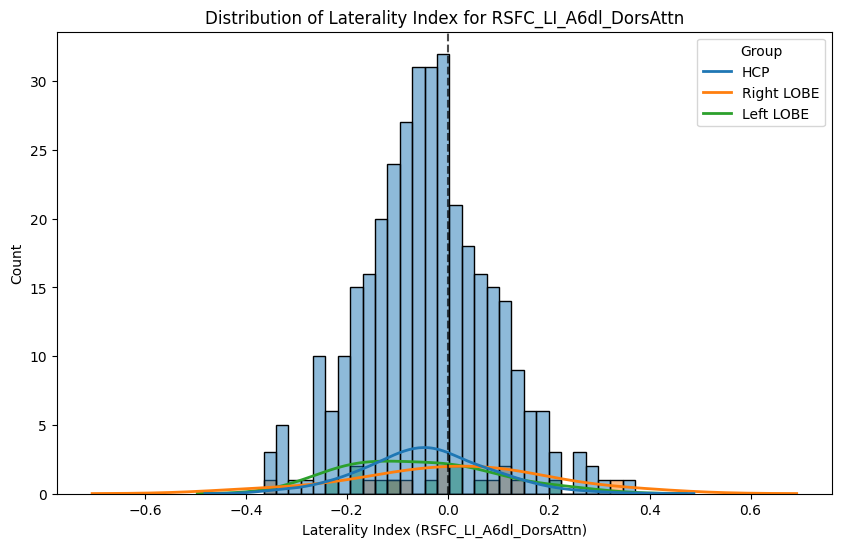

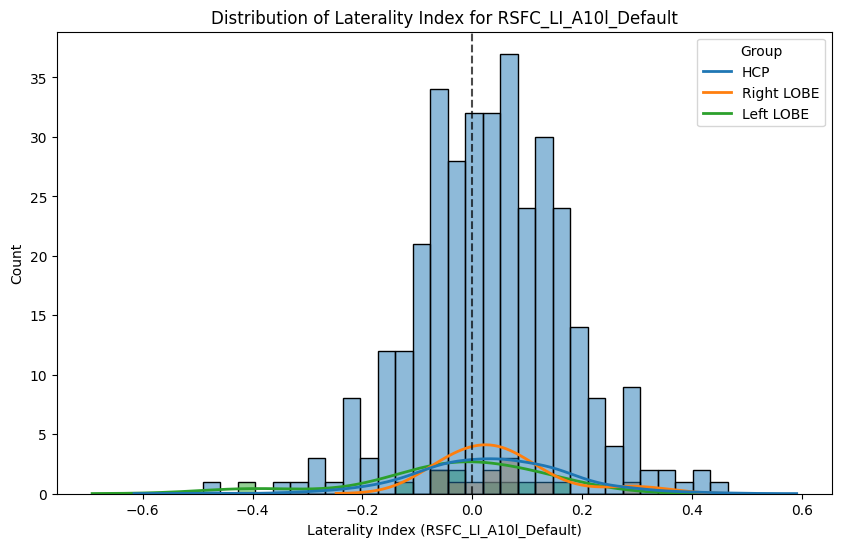

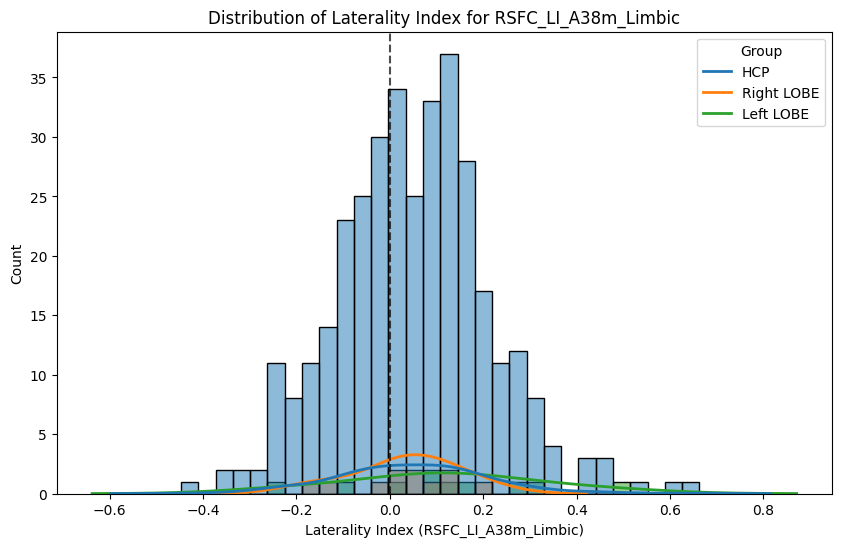

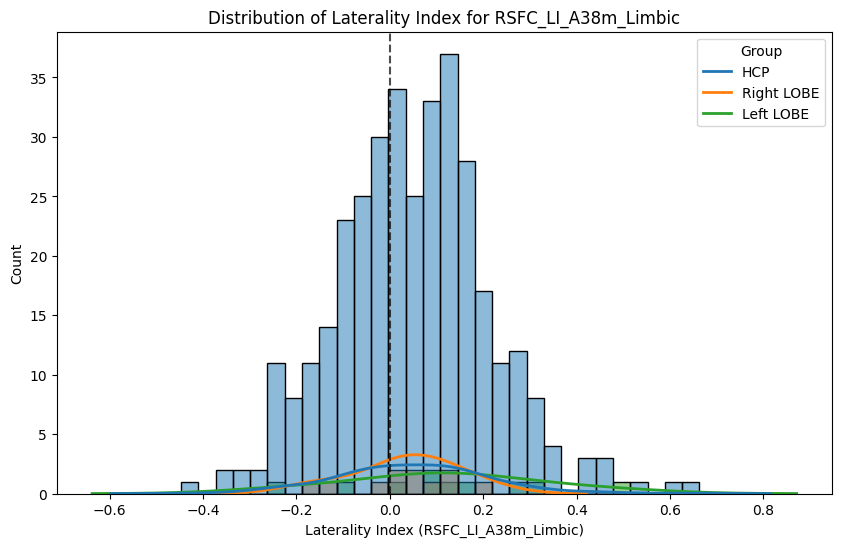

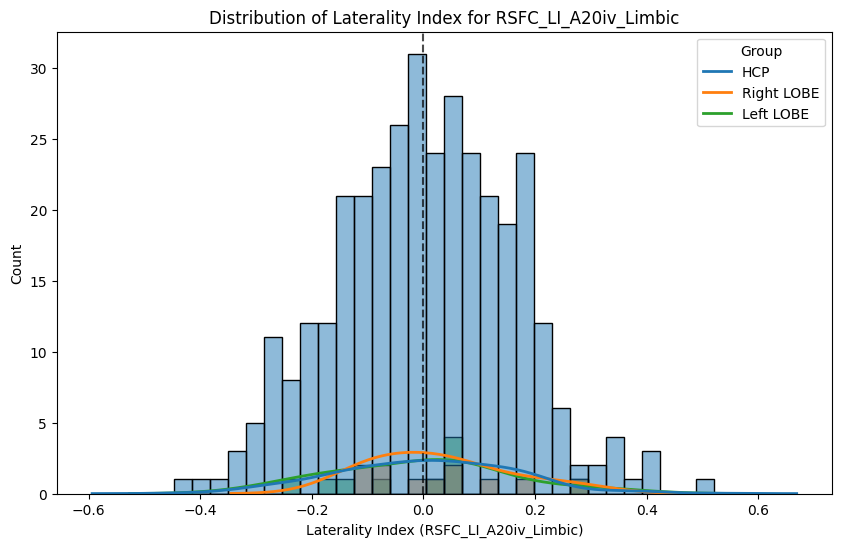

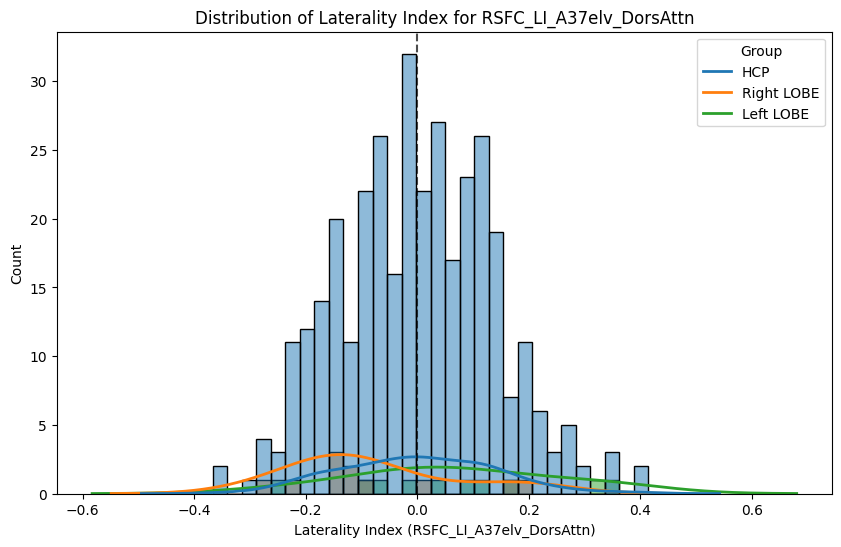

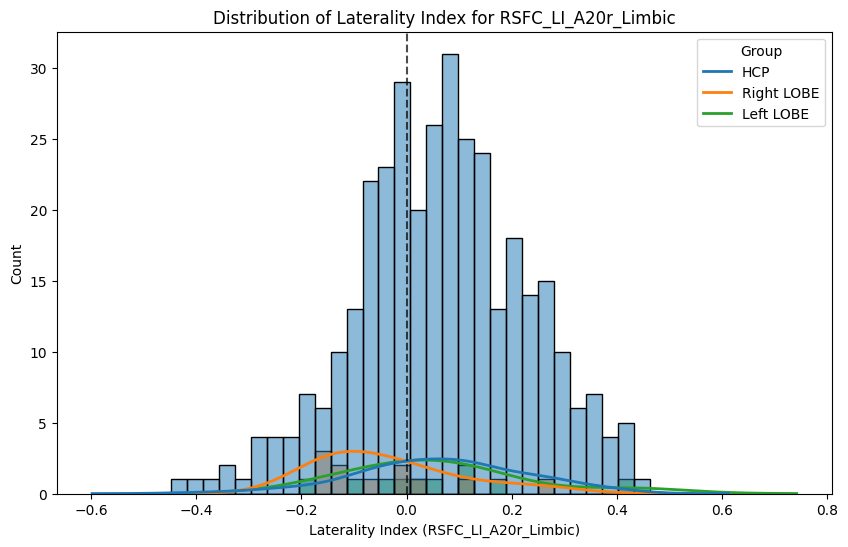

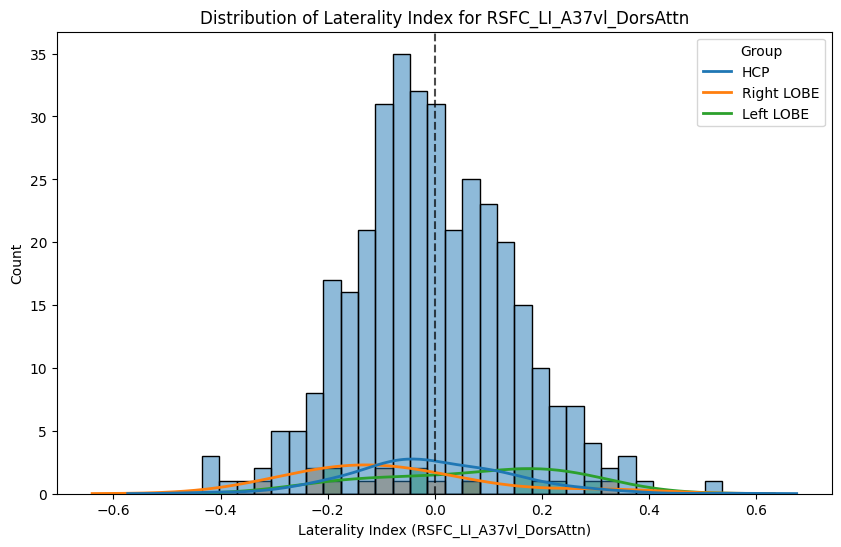

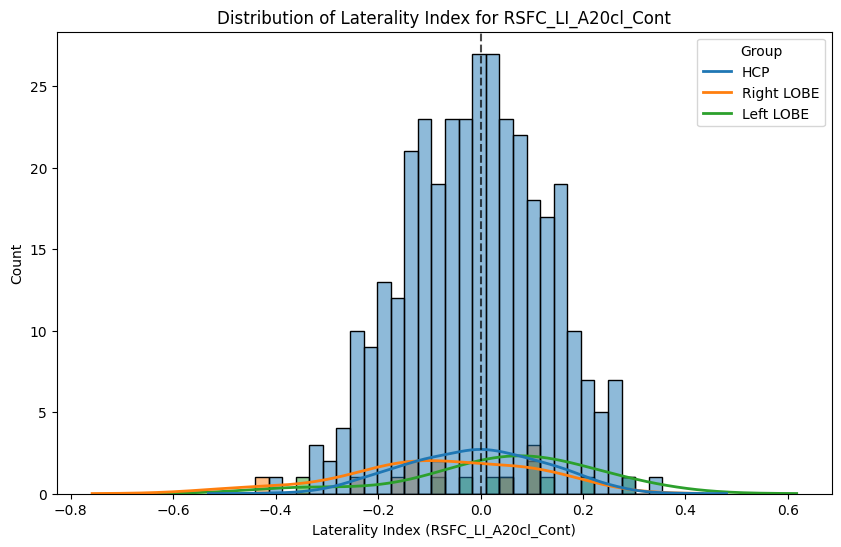

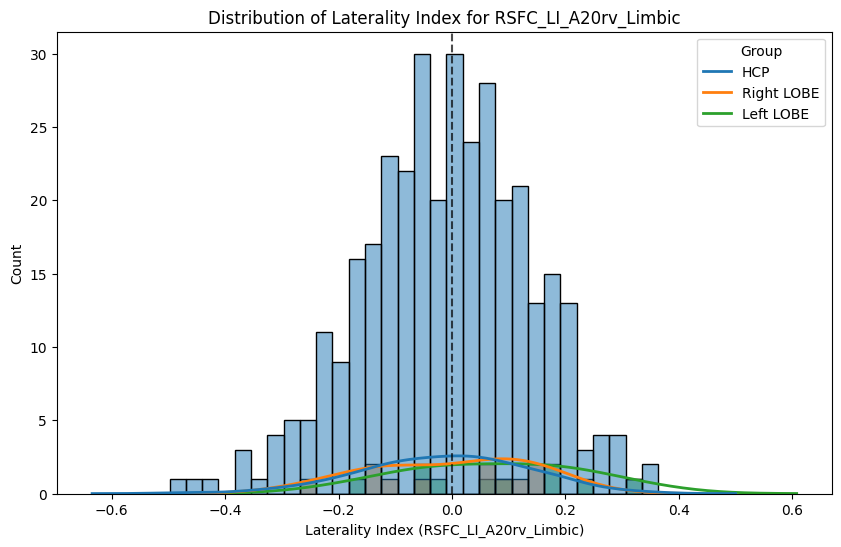

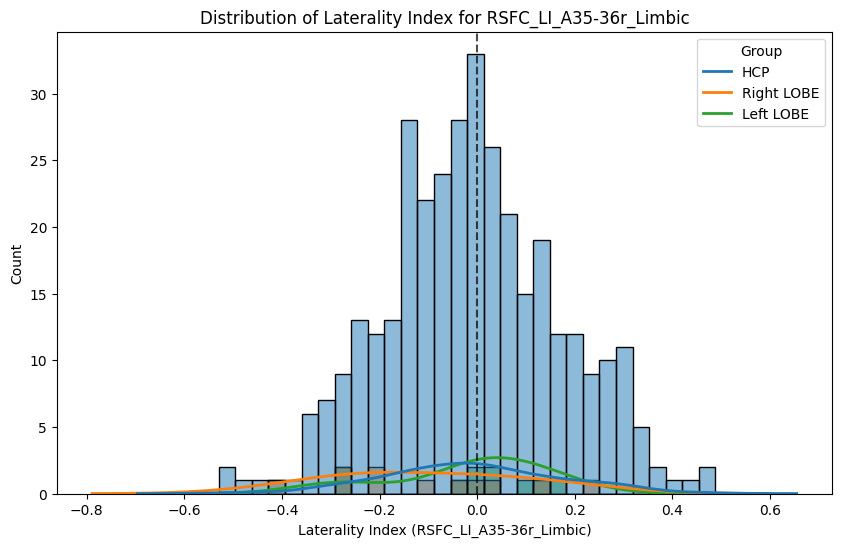

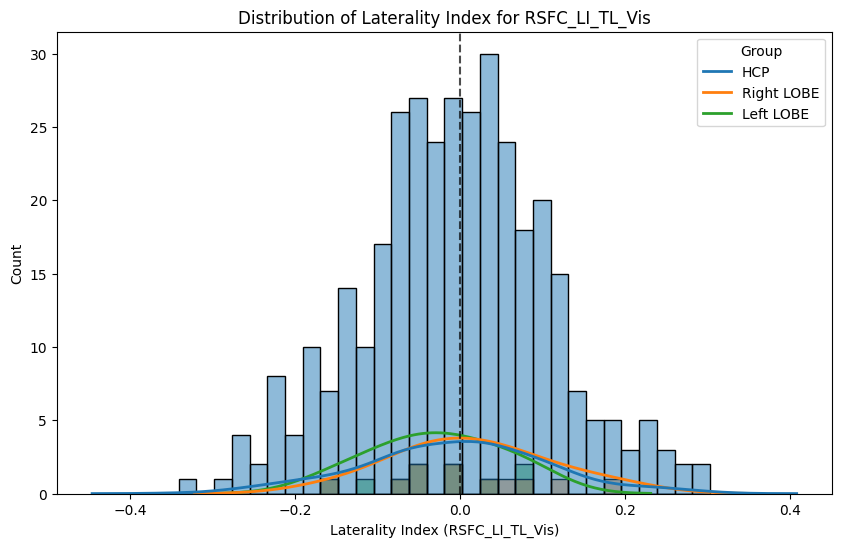

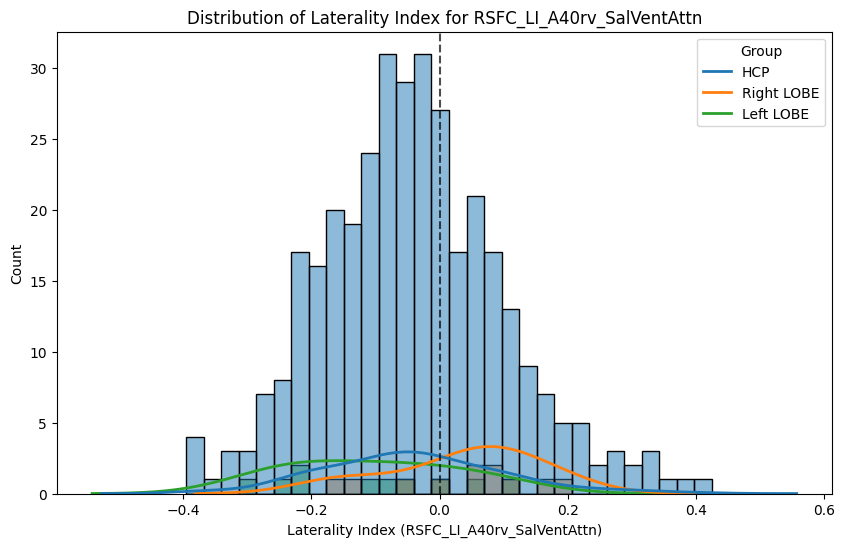

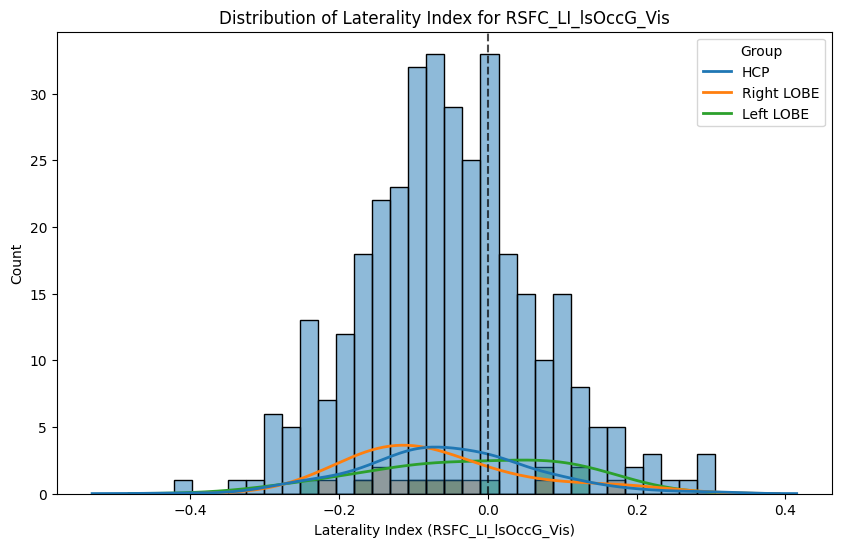

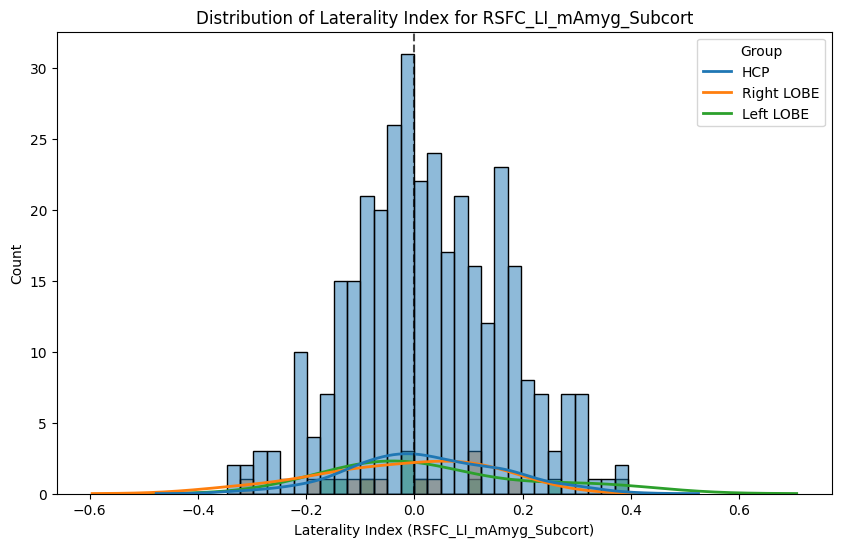

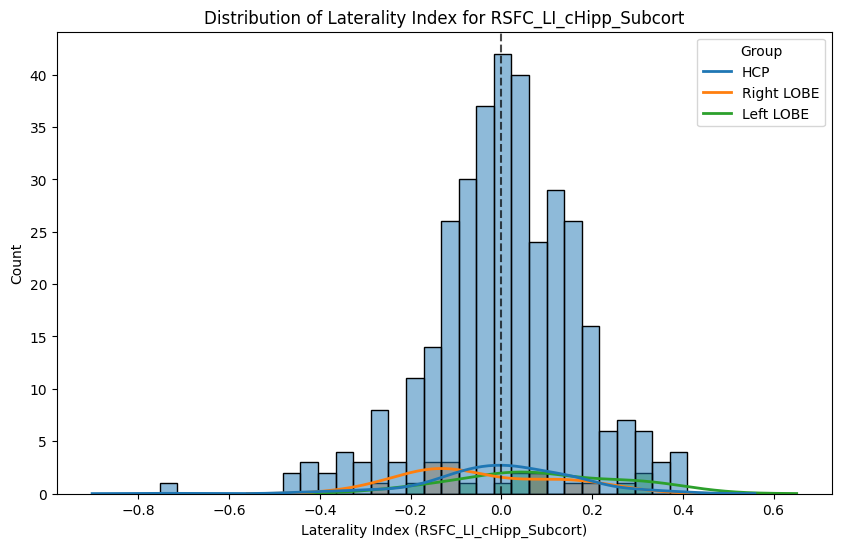

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the significant regions file
stats_path = "../results/stats_Mar25/ols_rsfc_results_with_covariates.tsv"
df_stats = pd.read_csv(stats_path, sep='\t')

# Filter for significant regions
significant_regions = df_stats[df_stats['rejected (FDR significant)'] == True]['RSFC_column'].tolist()

# Convert contra/ipsi to LI format
target_regions = [region.replace('contra', 'LI').replace('ipsi', 'LI') for region in significant_regions]

# Load the laterality index dataset
laterality_path = "../resources/laterality_index.tsv"
laterality_df = pd.read_csv(laterality_path, sep='\t')

# Define participant groups
laterality_df['Group'] = 'HCP'  # Default to HCP
laterality_df.loc[laterality_df['participant_id'].isin(left_sided_subs_lobe), 'Group'] = 'Left LOBE'
laterality_df.loc[laterality_df['participant_id'].isin(right_sided_subs_lobe), 'Group'] = 'Right LOBE'

# Loop through each target region and create plots
for region in target_regions:
    if region not in laterality_df.columns:
        print(f"Skipping {region}, not found in laterality_df")
        continue  # Skip missing regions
    
    plt.figure(figsize=(10, 6))
    
    # Plot histogram
    sns.histplot(
        data=laterality_df, 
        x=region, 
        hue="Group", 
        bins=30, 
        stat="count",
        alpha=0.5, 
        multiple="layer",
      #  hue_order=["HCP", "Left LOBE", "Right LOBE"],
     #   palette={"HCP": "blue", "Left LOBE": "red", "Right LOBE": "green"}
    )

    # Overlay KDE line
    sns.kdeplot(
        data=laterality_df, 
        x=region, 
        hue="Group", 
        common_norm=False, 
        linewidth=2,
      #  hue_order=["HCP", "Left LOBE", "Right LOBE"],
      #  palette={"HCP": "blue", "Left LOBE": "red", "Right LOBE": "green"}
    )

    # Add vertical reference line at LI = 0
    plt.axvline(0, color='black', linestyle='--', alpha=0.7)

    plt.xlabel(f"Laterality Index ({region})")
    plt.ylabel("Count")
    plt.title(f"Distribution of Laterality Index for {region}")

   # plt.legend(title="Group", labels=["HCP","Left LOBE","Right LOBE"], loc="upper right")
    plt.show()

### -1 = right dominant, +1 = 

In [14]:
# Linear model

In [40]:
df_tabular = pd.read_csv('../resources/laterality_index.tsv',sep='\t')

# Convert 'sex' to numeric if it's categorical (assuming 'male' and 'female')
df_tabular['sex'] = df_tabular['sex'].map({'M': 1, 'F': 0})

# Convert 'dataset' to numeric (LOBE = 0, HCP = 1)
df_tabular['dataset'] = df_tabular['dataset'].map({'LOBE': 1, 'HCP': 0})


# Identify columns that start with 'R_'
r_columns = [col for col in df_tabular.columns if col.startswith('RSFC_')]

# Lists to store results
model_params, pvals_list = [], []

# Loop over each R_ column to fit the OLS model
for col in r_columns:
    # Define the independent variables (covariates + dataset)
    X = df_tabular[['age', 'sex', 'dataset']]
    
    # Add a constant term (intercept) to the model
    X = sp.add_constant(X)
    
    # Define the dependent variable (R_ column)
    y = df_tabular[col]
    
    # Fit the OLS model
    model = sp.OLS(y, X).fit()
    
    # Get the p-value and coefficient for the 'dataset' variable (testing for difference between LOBE and HCP)
    model_params.append(model.params['dataset'])
    pvals_list.append(model.pvalues['dataset'])

# Store the results in a DataFrame
results_df = pd.DataFrame({
    'RSFC_column': r_columns,
    'dataset_coefficient': model_params,
    'p-value': pvals_list
})

# Apply FDR correction for multiple comparisons
rejected, corr_pvals = fdrcorrection(pvals_list, alpha=0.05)

# Add FDR-corrected p-values and rejected boolean to the results
results_df['corrected p-value'] = corr_pvals
results_df['rejected (FDR significant)'] = rejected

# Save the results to a TSV file
results_df.to_csv('../results/stats_Mar25/ols_rsfc_results_with_covariates.tsv', sep='\t', index=False)

# Filter the DataFrame to only include significant results (rejected == True)
significant_results_df = results_df[results_df['rejected (FDR significant)']]

# Save the filtered results as a TSV file
significant_results_df.to_csv('../results/stats_Mar25/ols_rsfc_fdr_significant_results.tsv', sep='\t', index=False)

In [94]:
df_tabular = pd.read_csv('../resources/merged_tabular_withconn_flipped.tsv',sep='\t')

# Filter the DataFrame for rows where 'dataset' is 'LOBE'
df_lobe = df_tabular[df_tabular['dataset'] == 'LOBE']

# Calculate statistics for the 'age' column
age_mean = df_lobe['asm_first_scan'].mean()
age_std = df_lobe['asm_first_scan'].std()
age_min = df_lobe['asm_first_scan'].min()
age_max = df_lobe['asm_first_scan'].max()
age_range = age_max - age_min

# Print the results
print(f"Age Mean: {age_mean:.2f}")
print(f"Age Standard Deviation: {age_std:.2f}")
print(f"Age Range: {age_min} - {age_max} ({age_range})")


Age Mean: 2.14
Age Standard Deviation: 0.96
Age Range: 1.0 - 4.0 (3.0)


In [91]:
# Count the occurrences of each sex category for LOBE subjects
sex_counts = df_tabular[df_tabular['dataset'] == 'HCP']['sex'].value_counts()

# Print the results
print(sex_counts)


sex
F    182
M    159
Name: count, dtype: int64
